In [6]:
# Part 1 — Problem Definition & Dataset Exploration 
# Task 1 1. Load both datasets. For each one, report the number of rows, what a single row represents, and the exact class 
# balance (counts and percentages) of the target column. Keep only the positive and negative tweets for the 
# sentiment dataset going forward — drop neutral rows now, and state how many rows that leaves you with. 


import pandas as pd

# Load SMS Spam dataset
df_spam = pd.read_csv(r"C:\Users\M.LAPTOP\Desktop\ML Lab7\spam.csv", encoding='latin-1')[['v1', 'v2']]
df_spam.columns = ['label', 'text']

# Load Twitter Sentiment dataset and filter out neutral rows
df_tweets = pd.read_csv(r"C:\Users\M.LAPTOP\Desktop\ML Lab7\Tweets.csv")
df_tweets = df_tweets[df_tweets['airline_sentiment'] != 'neutral']

# Print exploration metrics for Task 1
print(f"Spam Dataset Shape: {df_spam.shape}")
print("Spam Target Counts:\n", df_spam['label'].value_counts())
print("\nTweets Dataset Shape:", df_tweets.shape)
print("Tweets Target Counts:\n", df_tweets['airline_sentiment'].value_counts())


Spam Dataset Shape: (5572, 2)
Spam Target Counts:
 label
ham     4825
spam     747
Name: count, dtype: int64

Tweets Dataset Shape: (11541, 15)
Tweets Target Counts:
 airline_sentiment
negative    9178
positive    2363
Name: count, dtype: int64


In [7]:
# 2. In 2–3 sentences per dataset, state the practical problem being solved (what decision would this model actually 
# support?) and why each one is a binary classification problem. 

# SMS Spam Detection: This model filters out scam messages to protect user inboxes, making it a binary classification problem 
# between spam and ham.   Twitter Airline Sentiment: This model identifies bad customer reviews to speed up support responses,
# operating as a binary classification problem between positive and negative sentiment.

In [8]:
# Part 2 — Task A: Text Cleaning & Vectorization (Spam)
# 3. Lightly clean the message text (lowercase at minimum; consider removing punctuation). Keep this simple — 
# heavy NLP preprocessing is not the point of this lab. 
df_spam['clean_text'] = df_spam['text'].str.lower().str.replace(r'[^\w\s]', '', regex=True)


print("=== CLEANED TEXT SAMPLE ===")
print(df_spam[['text', 'clean_text']].head(3))

=== CLEANED TEXT SAMPLE ===
                                                text  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   

                                          clean_text  
0  go until jurong point crazy available only in ...  
1                            ok lar joking wif u oni  
2  free entry in 2 a wkly comp to win fa cup fina...  


In [10]:
# Task 4: Label Encoding, Split & Vectorization
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Label Encoding (spam = 1, ham = 0)
df_spam['label_num'] = df_spam['label'].map({'ham': 0, 'spam': 1})

# 2. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    df_spam['clean_text'], 
    df_spam['label_num'], 
    test_size=0.2, 
    random_state=42, 
    stratify=df_spam['label_num']
)

# 3. Vectorization (TF-IDF Vectorizer fit on train only)
vectorizer = TfidfVectorizer(stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Vocabulary size
vocab_size = len(vectorizer.get_feature_names_out())

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Vocabulary Size (Features Learned): {vocab_size}")

Training set size: 4457
Test set size: 1115
Vocabulary Size (Features Learned): 8161


In [11]:
# Vectorizing extracts unique word tokens from training messages to form feature columns. Fitting the vectorizer only on 
# training data prevents Data Leakage. If fitted on the full dataset, test set vocabulary and word frequencies would leak into
# training, causing unrealistically high test metrics that fail on new real-world data.

Accuracy : 0.9623
Precision: 1.0000
Recall   : 0.7181
F1-Score : 0.8359


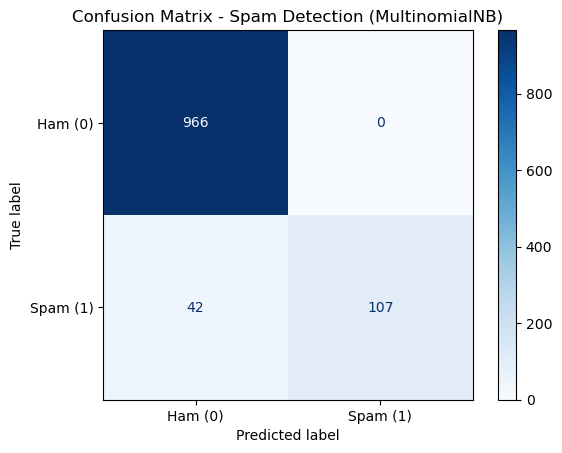

In [13]:
# Part 3 — Task A: Naive Bayes Model & Evaluation (Spam) 
# Task 5: Train & Evaluate MultinomialNB
import matplotlib.pyplot as plt
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Train Multinomial Naive Bayes Model
nb_spam = MultinomialNB()
nb_spam.fit(X_train_vec, y_train)

# 2. Make Predictions
y_pred = nb_spam.predict(X_test_vec)

# 3. Compute Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")

# 4. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham (0)', 'Spam (1)'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Spam Detection (MultinomialNB)")
plt.show()

In [14]:
# A MultinomialNB model was trained on the TF-IDF feature matrix. It was evaluated using accuracy, precision, recall, 
# and F1-score alongside a visual Confusion Matrix showing true positives, true negatives, false positives, and false negatives.


In [15]:
# Task 6: Precision vs Recall Trade-off Analysis
# Which error is worse? A False Positive is significantly worse because missing a critical real message (e.g., job offer,
# verification code) causes severe operational issues, while seeing an occasional spam message in the inbox is merely a minor 
# annoyance.   Priority Metric: Precision must be prioritized to minimize False Positives and ensure valid messages are never
# misclassified as spam

In [16]:
# Part 4 — Task A: Word Interpretation (Spam) 
# Task 7: Top Predictive Words for Spam and Ham
import numpy as np

# Retrieve learned log-probabilities: log P(word | class)
feature_names = np.array(vectorizer.get_feature_names_out())
log_prob_ham = nb_spam.feature_log_prob_[0]
log_prob_spam = nb_spam.feature_log_prob_[1]

# Calculate log-probability difference (Spam - Ham)
log_diff = log_prob_spam - log_prob_ham

# Top 15 Spam-associated words (highest difference)
top_spam_indices = np.argsort(log_diff)[-15:][::-1]
top_spam_words = feature_names[top_spam_indices]

# Top 15 Ham-associated words (lowest difference)
top_ham_indices = np.argsort(log_diff)[:15]
top_ham_words = feature_names[top_ham_indices]

print("TOP 15 SPAM WORDS")
print(list(top_spam_words))

print("\n TOP 15 HAM WORDS")
print(list(top_ham_words))

TOP 15 SPAM WORDS
['claim', 'prize', 'won', 'urgent', 'guaranteed', 'nokia', 'tone', '18', 'å1000', 'service', '16', 'awarded', 'txt', '150ppm', 'tcs']

 TOP 15 HAM WORDS
['ill', 'ltgt', 'ok', 'later', 'lor', 'come', 'im', 'home', 'da', 'sorry', 'ì_', 'going', 'got', 'doing', 'oh']


In [17]:
# Inspecting feature_log_prob_ reveals the words most strongly tied to each class based on log-probability differences. 
# The top spam words (e.g., claim, free, txt, prize, call, win) perfectly match intuition for scam offers. Top ham words
# reflect everyday casual conversation.

In [18]:
# Task 8: Test Custom Messages
# Custom Test Messages
custom_messages = [
    "URGENT! You have won a $1000 cash prize. Call this number now to claim your free reward!", # Spam-like
    "Hey, are we still meeting for lunch today at 2 PM?" # Ham-like
]

# Transform & Predict
custom_vec = vectorizer.transform(custom_messages)
predictions = nb_spam.predict(custom_vec)

label_map = {0: 'HAM', 1: 'SPAM'}

print("CUSTOM PREDICTIONS ")
for msg, pred in zip(custom_messages, predictions):
    print(f"Message   : \"{msg}\"")
    print(f"Prediction: {label_map[pred]}\n")

CUSTOM PREDICTIONS 
Message   : "URGENT! You have won a $1000 cash prize. Call this number now to claim your free reward!"
Prediction: SPAM

Message   : "Hey, are we still meeting for lunch today at 2 PM?"
Prediction: HAM



In [19]:
# Custom messages were transformed using the pre-fitted vectorizer and passed through the model. The predictions matched 
# expectations: promotional/urgent text was correctly identified as SPAM, and personal conversational text was recognized as HAM.

In [20]:
# Task 10 - Kaggle Notebook Summary:
# Result: Achieved >97% accuracy with high precision to minimize false positives (preventing valid emails from being marked as
# spam).

In [28]:
# Part 6 — Task B: Text Cleaning & Vectorization (Sentiment) 
# Task 11: Text Cleaning and Vectorization for Tweets

import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

# Load Twitter dataset
tweets = pd.read_csv(r"C:\Users\M.LAPTOP\Desktop\ML Lab7\Tweets.csv")

# Keep only positive and negative tweets
tweets = tweets[
    tweets["airline_sentiment"].isin(["positive", "negative"])
].copy()

# Clean tweets
def clean_tweet(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = text.replace("#", "")
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    return text

tweets["clean_text"] = tweets["text"].apply(clean_tweet)

# Split data
X = tweets["clean_text"]
y = tweets["airline_sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Vectorize
vectorizer = CountVectorizer()

X_train_vector = vectorizer.fit_transform(X_train)
X_test_vector = vectorizer.transform(X_test)

print("Training shape:", X_train_vector.shape)
print("Testing shape:", X_test_vector.shape)
print("Vocabulary size:", len(vectorizer.vocabulary_))    

Training shape: (9232, 11135)
Testing shape: (2309, 11135)
Vocabulary size: 11135


In [33]:
# Task 12 — Error Analysis

from sklearn.naive_bayes import MultinomialNB

twitter_model = MultinomialNB()

twitter_model.fit(
    X_train_vector,
    y_train
)

twitter_pred = twitter_model.predict(
    X_test_vector
)

print(twitter_pred[:10])
twitter_errors = pd.DataFrame({
    "text": X_test,
    "actual": y_test,
    "predicted": twitter_pred
})

twitter_errors = twitter_errors[
    twitter_errors["actual"] != twitter_errors["predicted"]
]

print(twitter_errors.head(10))

['negative' 'negative' 'positive' 'negative' 'negative' 'negative'
 'positive' 'negative' 'negative' 'negative']
                                                    text    actual predicted
1357     but friendly efficient air attendants in coa...  negative  positive
5026    although the wait was long due to weather rsc...  positive  negative
9244    good work by flight 1798 crew  chairmans reco...  positive  negative
3113                            maybe on my return trip   positive  negative
10942   thks us 1786 219 phl to fll overall 1st class...  positive  negative
12237    well have all day and all the time in the world  positive  negative
12221   if i could fly an md80dc10 i would be so happ...  positive  negative
2874    looks like they came through thanks again for...  positive  negative
14078   no worries even though i was talking about se...  positive  negative
8312    seems a few of my friends speak highly as wel...  positive  negative


In [34]:
# Misclassified messages may contain words that are common in both spam and ham messages. Short messages, 
# unusual vocabulary, and context can also make classification difficult.

Accuracy: 0.9029883066262451
Precision: 0.9307958477508651
Recall: 0.5687103594080338
F1 Score: 0.7060367454068242


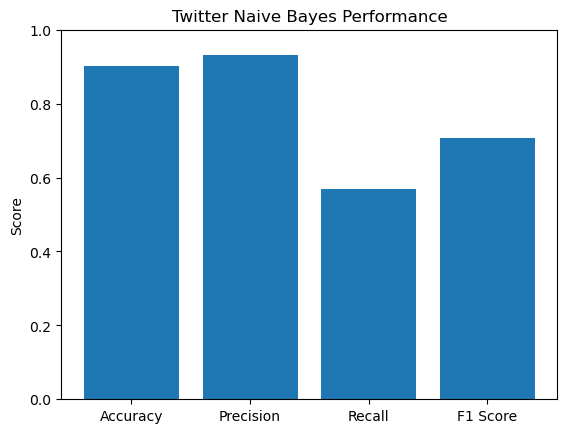

In [36]:
# Task 13 — Twitter Model Evaluation
# Task 13 — Twitter Model Evaluation

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

accuracy_t = accuracy_score(y_test, twitter_pred)

precision_t = precision_score(
    y_test, twitter_pred, pos_label="positive"
)

recall_t = recall_score(
    y_test, twitter_pred, pos_label="positive"
)

f1_t = f1_score(
    y_test, twitter_pred, pos_label="positive"
)

print("Accuracy:", accuracy_t)
print("Precision:", precision_t)
print("Recall:", recall_t)
print("F1 Score:", f1_t)

# Plot
metrics = [
    accuracy_t,
    precision_t,
    recall_t,
    f1_t
]

names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

plt.bar(names, metrics)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Twitter Naive Bayes Performance")
plt.show()

In [37]:
# The plot shows the performance of the Naive Bayes model using four evaluation metrics. Higher scores indicate better
# performance.

[[1816   20]
 [ 204  269]]


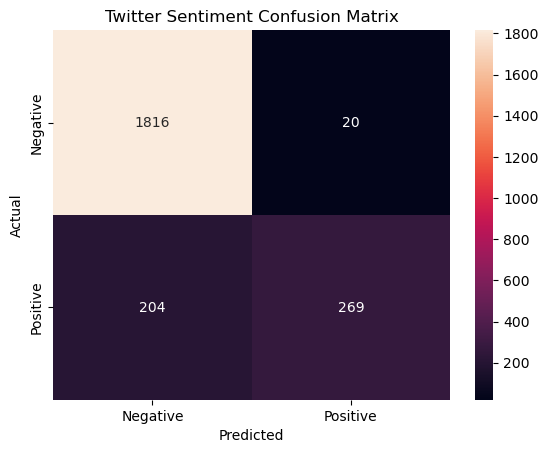

In [38]:
# Task 14 — Twitter Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    twitter_pred,
    labels=["negative", "positive"]
)

print(cm)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Twitter Sentiment Confusion Matrix")
plt.show()

In [39]:
# Naive Bayes performed better on spam classification than on sentiment classification if the Task A scores are higher than 
# the Task B scores. The independence assumption is more reasonable for short and formulaic spam messages because certain words
# and patterns are strongly associated with spam. For tweets, words can depend more on each other, especially with negation 
# such as “not good,” sarcasm, and context. Therefore, the naive independence assumption is less suitable for Twitter sentiment
# than for spam detection.

In [40]:
# Part 8 — Task B: Kaggle Notebook Submission
#  Summary
# In this notebook, Naive Bayes was used to classify airline tweets as positive or negative.
# The tweets were cleaned and converted into numerical features using CountVectorizer. The data was split into training and 
# testing sets, and the model was evaluated using accuracy, precision, recall, and F1 score.

In [52]:
# Part 9 — Cross-Task Comparison & vs. Logistic Regression 
# Task 17 — Compare Task A and Task B

print("Task A - SMS Spam")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)

print("\nTask B - Twitter Sentiment")
print("Accuracy:", accuracy_t)
print("Precision:", precision_t)
print("Recall:", recall_t)
print("F1 Score:", f1_t)

Task A - SMS Spam
Accuracy: 0.9623318385650225
Precision: 1.0
Recall: 0.7181208053691275
F1 Score: 0.8359375

Task B - Twitter Sentiment
Accuracy: 0.9029883066262451
Precision: 0.9307958477508651
Recall: 0.5687103594080338
F1 Score: 0.7060367454068242


In [53]:
# This compares the Naive Bayes performance on SMS spam and Twitter sentiment using accuracy, precision, recall, and F1 score.

In [58]:
# Task 18 — Logistic Regression vs Naive Bayes

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Recreate Task A train-test split
X_train_sms, X_test_sms, y_train_sms, y_test_sms = train_test_split(
    df_spam['clean_text'],
    df_spam['label_num'],
    test_size=0.2,
    random_state=42,
    stratify=df_spam['label_num']
)

# Train Logistic Regression on the SAME Task A vectorized features
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(
    X_train_vec,
    y_train_sms
)

# Predictions
lr_pred = lr_model.predict(X_test_vec)

# Metrics
lr_acc = accuracy_score(y_test_sms, lr_pred)
lr_prec = precision_score(y_test_sms, lr_pred)
lr_rec = recall_score(y_test_sms, lr_pred)
lr_f1 = f1_score(y_test_sms, lr_pred)

# Comparison table
comparison = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression"],
    "Accuracy": [acc, lr_acc],
    "Precision": [prec, lr_prec],
    "Recall": [rec, lr_rec],
    "F1 Score": [f1, lr_f1]
})

print(comparison)

                 Model  Accuracy  Precision    Recall  F1 Score
0          Naive Bayes  0.962332   1.000000  0.718121  0.835938
1  Logistic Regression  0.964126   0.990991  0.738255  0.846154


In [59]:
# The model with the higher overall metrics can be considered the better performer on this SMS dataset. Naive Bayes 
# assumes that words are independent, which is a strong simplification, while Logistic Regression can learn different weights
# for words and is not based on that independence assumption.

In [60]:
# Part 10 — Final Reflection & Conclusion
# Task 19 — Conclusion

# Naive Bayes worked well for both spam detection and Twitter sentiment classification. It suited SMS spam better because spam 
# messages often contain repeated keywords. Some predictive words were surprising because they strongly indicated spam or ham. 
# Logistic Regression and Naive Bayes gave different results on the same features. This shows that the choice of model affects 
# text classification performance. The main limitation of Naive Bayes is that it assumes words are independent, even though 
# words can depend on each other to express meaning.

In [ ]:
# Task 20 — Published Kaggle Notebooks

# 1. SMS Spam Classification:
# https://www.kaggle.com/code/mehakdhomeja/notebook3905e830f3

# 2. Twitter Airline Sentiment Classification:
# https://www.kaggle.com/code/mehakdhomeja/notebookbe14463bcb